In [ ]:
# Notebook setup: run once per kernel
import os
import sys
from pathlib import Path

# Ensure we run from project root (so relative paths work)
root = Path.cwd().resolve()
for _ in range(5):
    if (root / "lungcancer3d").exists():
        break
    root = root.parent
os.chdir(root)
print("Project root:", Path.cwd())

# Install dependencies into the current notebook kernel
!{sys.executable} -m pip install -q -r requirements.txt

# Visualize Model Predictions
This notebook loads the trained checkpoint from `outputs/checkpoints/best_model.pth` and runs inference on a few example 3D patches (`64×64×64`).

You can sample patches from either:
- The extracted folder `./data` (recommended), or
- The nested archive `data_raw/luna16_processed.zip` (no full extraction required).

Outputs: mid-slice visualization + predicted probability + label interpretation at a chosen threshold.

In [ ]:
import os
import io
import random
from pathlib import Path
import zipfile

import numpy as np
import torch
import matplotlib.pyplot as plt

# Repro + device
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from lungcancer3d.model import LungCancer3DCNN

Using device: cpu
Successfully imported LungCancer3DCNN from model.py


In [ ]:
# Load checkpoint + model
model_path = Path("outputs/checkpoints/best_model.pth")
if not model_path.exists():
    raise FileNotFoundError(f"{model_path} not found. Train first or place the checkpoint there.")

checkpoint = torch.load(str(model_path), map_location=device)
state_dict = checkpoint["model_state_dict"] if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint

model = LungCancer3DCNN().to(device)
model.load_state_dict(state_dict)
model.eval()

print(f"✓ Loaded model from {model_path}")
if isinstance(checkpoint, dict):
    print(f"  Val accuracy (checkpoint): {checkpoint.get('val_accuracy', 0):.4f}")

✓ Model loaded from best_model.pth
  Best Validation Accuracy: 0.9338


Opening luna16_processed.zip...
Checking inside lung_cancer_processed_dataset/subset0_processed.zip...
Found 2 samples to test.

Processing: 1.3.6.1.4.1.14519.5.2.1.6279.6001.323302986710576400812869264321_pos_889.npy (from lung_cancer_processed_dataset/subset0_processed.zip)
Loaded shape: (64, 64, 64)


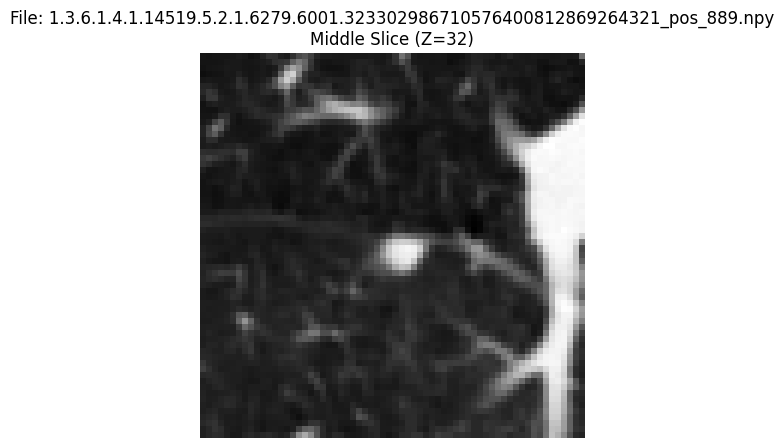

Model Prediction Score: 0.9190
Interpretation: CANCER (Positive)
--------------------------------------------------

Processing: 1.3.6.1.4.1.14519.5.2.1.6279.6001.144438612068946916340281098509_neg_112932.npy (from lung_cancer_processed_dataset/subset0_processed.zip)
Loaded shape: (64, 64, 64)


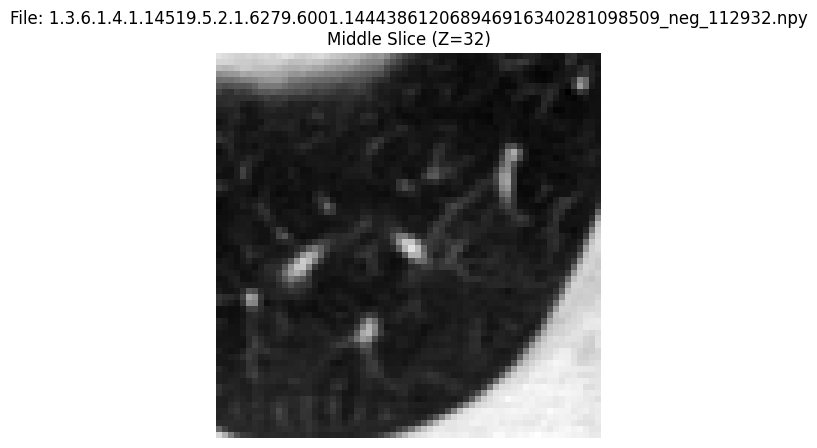

Model Prediction Score: 0.0020
Interpretation: NORMAL (Negative)
--------------------------------------------------


In [ ]:
# --- CONFIG ---
THRESHOLD = 0.50
DATA_DIR = Path("data")                    # extracted patches
ZIP_PATH = Path("data_raw/luna16_processed.zip")  # optional alternative source
MAX_SAMPLES = 4  # how many examples to show

def _predict_probability(volume_64: np.ndarray) -> float:
    """volume_64: (64,64,64) float32"""
    x = torch.from_numpy(volume_64).float().unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        logit = model(x).view(-1)
        prob = torch.sigmoid(logit).item()
    return float(prob)

def _show_mid_slice(volume_64: np.ndarray, title: str):
    z = volume_64.shape[0] // 2
    plt.figure(figsize=(5, 5))
    plt.imshow(volume_64[z], cmap="gray")
    plt.title(f"{title}\nmid-slice z={z}")
    plt.axis("off")
    plt.show()

def _load_random_from_data_dir(data_dir: Path) -> list[tuple[str, np.ndarray]]:
    if not data_dir.exists():
        return []
    files = list(data_dir.rglob("*.npy"))
    if not files:
        return []
    pos_files = [p for p in files if "_pos_" in p.stem]
    neg_files = [p for p in files if "_neg_" in p.stem]
    picks: list[Path] = []
    if pos_files:
        picks.append(random.choice(pos_files))
    if neg_files:
        picks.append(random.choice(neg_files))
    while len(picks) < min(MAX_SAMPLES, len(files)) and len(picks) < MAX_SAMPLES:
        picks.append(random.choice(files))
    samples: list[tuple[str, np.ndarray]] = []
    for p in picks:
        arr = np.load(p).astype(np.float32)
        samples.append((str(p), arr))
    return samples

def _load_samples_from_nested_zip(zip_path: Path) -> list[tuple[str, np.ndarray]]:
    if not zip_path.exists():
        return []
    samples: list[tuple[str, np.ndarray]] = []
    with zipfile.ZipFile(zip_path, "r") as outer:
        outer_files = outer.namelist()
        subset_zips = [f for f in outer_files if f.endswith(".zip")]
        for inner_name in subset_zips:
            if len(samples) >= MAX_SAMPLES:
                break
            inner_data = outer.read(inner_name)
            with zipfile.ZipFile(io.BytesIO(inner_data)) as inner:
                inner_files = [f for f in inner.namelist() if f.endswith(".npy")]
                if not inner_files:
                    continue
                random.shuffle(inner_files)
                for npy_name in inner_files:
                    if len(samples) >= MAX_SAMPLES:
                        break
                    blob = inner.read(npy_name)
                    arr = np.load(io.BytesIO(blob)).astype(np.float32)
                    samples.append((f"{inner_name}:{npy_name}", arr))
    return samples

def run_demo():
    samples = _load_random_from_data_dir(DATA_DIR)
    source = "data/"
    if not samples:
        samples = _load_samples_from_nested_zip(ZIP_PATH)
        source = str(ZIP_PATH)
    if not samples:
        raise FileNotFoundError("No samples found. Run python -m scripts.setup_data or provide data_raw/luna16_processed.zip")

    print(f"Using samples from: {source} (n={len(samples)})")
    for name, arr in samples:
        if arr.shape != (64, 64, 64):
            print(f"Skipping {name} (shape={arr.shape})")
            continue
        prob = _predict_probability(arr)
        pred = 1 if prob >= THRESHOLD else 0
        _show_mid_slice(arr, title=Path(name).name if ":" not in name else name)
        print(f"{name}")
        print(f"  prob={prob:.4f}  threshold={THRESHOLD:.2f}  pred={pred}")
        print("-" * 60)

run_demo()